# Random Forest w/Expanded Features & Weighting Comparison

In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


## 1) Load data

In [2]:
import joblib
import pandas as pd
from scipy import sparse
from pathlib import Path

data_dir = Path("../3_Data_Preprocessing/preprocessing_data")

X_train_sparse = sparse.load_npz(data_dir / "X_train_sparse_rf.npz")
X_test_sparse = sparse.load_npz(data_dir / "X_test_sparse_rf.npz")

y_train = pd.read_csv(data_dir / "y_train_rf.csv").squeeze()
y_test = pd.read_csv(data_dir / "y_test_rf.csv").squeeze()

preprocessor = joblib.load(data_dir / "rf_preprocessor.joblib")

# 2) Train Random Forest (using balanced subsample)

### balanced_subsample -- CLASS IMBALANCE HANDLING
We use class_weight="balanced_subsample" to address class imbalance in the poverty_risk_score labels. Random Forest trains each tree on a bootstrap sample of the training data (a resampled subset). With "balanced_subsample", sklearn recomputes class weights separately for each tree based on that tree’s bootstrap sample class distribution.
Strengths:
 - More robust when bootstrap samples have slightly different class proportions (weights adapt per tree).
 - Often a bit more stable / less aggressive than global reweighting, reducing the risk of over-correcting.
 - Can work well when you want imbalance handling but still want the forest to reflect natural variationacross bootstrap samples.
Weaknesses / tradeoffs:
 - Because weights vary per tree and can be less aggressive overall, minority-class precision/recall gains
   may be smaller than with global "balanced".
 - If minority classes are consistently under-predicted, this approach may not push the model enough.
Practical expectation: Tends to improve minority sensitivity compared to no weighting, while being somewhat conservative.


In [3]:
# RF w/class_weight="balanced_subsample" 
rf_bss = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample", # set to account for class imbalance in povpip
    random_state=42,
    n_jobs=-1
)

rf_bss.fit(X_train_sparse, y_train)

y_pred_bss = rf_bss.predict(X_test_sparse)

print("=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_bss))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_bss))


=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78    233793
           1       0.24      0.42      0.30     38456
           2       0.16      0.25      0.20     15534
           3       0.23      0.57      0.33     16585

    accuracy                           0.62    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.62      0.67    304368

Confusion matrix:
[[158318  44004  12018  19453]
 [  9508  16082   5829   7037]
 [  2633   4745   3930   4226]
 [  1860   2607   2705   9413]]


### balanced -- CLASS IMBALANCE HANDLING
We use class_weight="balanced" to address class imbalance in the poverty_risk_score labels. With "balanced", sklearn computes class weights *once* from the full training set:
weight_c = n_samples / (n_classes * n_samples_in_class_c)
These fixed weights are then applied consistently across all trees in the forest.
Strengths:
- More direct / stronger correction for class imbalance than "balanced_subsample".
- Can improve minority-class performance (often macro F1, sometimes minority precision) because minorityerrors are penalized more uniformly across the whole forest.
- Easier to reason about and reproduce because weights do not vary tree-to-tree.
Weaknesses / tradeoffs:
- Can reduce majority-class recall and sometimes overall accuracy (common when shifting focus to minorities).
- If the true signal separating minority classes is weak, stronger weighting may increase false positives(e.g., predicting higher poverty risk more often).
Practical expectation: Often boosts minority recall/precision somewhat, but may trade off performance on the majority class.


In [4]:
# RF/w class_weight="balanced" 

rf_bal = RandomForestClassifier(
    n_estimators=400,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",   # changed from "balanced_subsample"
    random_state=42,
    n_jobs=-1
)

rf_bal.fit(X_train_sparse, y_train)

y_pred_bal = rf_bal.predict(X_test_sparse)

print("=== Random Forest Performance (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_bal))


=== Random Forest Performance (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78    233793
           1       0.24      0.42      0.30     38456
           2       0.16      0.26      0.20     15534
           3       0.23      0.57      0.33     16585

    accuracy                           0.62    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.62      0.67    304368

Confusion matrix:
[[158110  44005  12086  19592]
 [  9488  16144   5819   7005]
 [  2620   4733   3969   4212]
 [  1867   2608   2726   9384]]


## 5) Visualizations of Model Performance

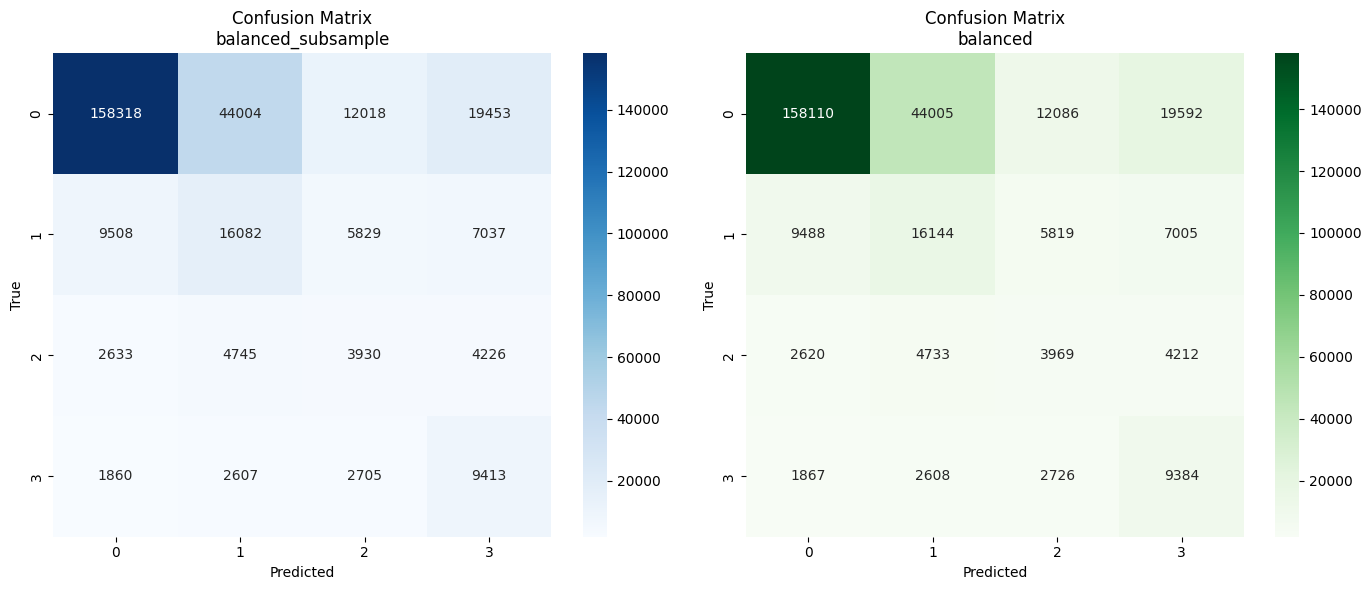

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_sub = confusion_matrix(y_test, y_pred_bss)
cm_bal = confusion_matrix(y_test, y_pred_bal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_sub, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix\nbalanced_subsample")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_bal, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix\nbalanced")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from sklearn.metrics import classification_report

report_sub = classification_report(y_test, y_pred_bss, output_dict=True)
report_bal = classification_report(y_test, y_pred_bal, output_dict=True)

rows = []

for c in ["0", "1", "2", "3"]:
    rows.append({
        "class": c,
        "precision_subsample": report_sub[c]["precision"],
        "precision_balanced": report_bal[c]["precision"],
        "recall_subsample": report_sub[c]["recall"],
        "recall_balanced": report_bal[c]["recall"],
        "f1_subsample": report_sub[c]["f1-score"],
        "f1_balanced": report_bal[c]["f1-score"],
    })

df_compare = pd.DataFrame(rows)
df_compare


,class,precision_subsample,precision_balanced,recall_subsample,recall_balanced,f1_subsample,f1_balanced
0,0,0.918750,0.918790,0.677172,0.676282,0.779677,0.779101
1,1,0.238471,0.239206,0.418192,0.419804,0.303738,0.304759
2,2,0.160526,0.161341,0.252993,0.255504,0.196421,0.197787
3,3,0.234569,0.233473,0.567561,0.565812,0.331946,0.330551


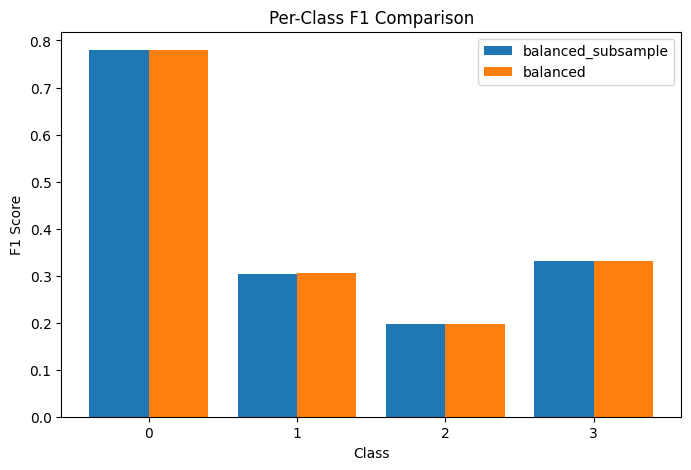

In [7]:
import matplotlib.pyplot as plt

x = range(len(df_compare))

plt.figure(figsize=(8,5))
plt.bar([i-0.2 for i in x], df_compare["f1_subsample"], width=0.4, label="balanced_subsample")
plt.bar([i+0.2 for i in x], df_compare["f1_balanced"], width=0.4, label="balanced")

plt.xticks(x, df_compare["class"])
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Comparison")
plt.legend()
plt.show()


In [8]:
print("Macro F1 (subsample):", report_sub["macro avg"]["f1-score"])
print("Macro F1 (balanced) :", report_bal["macro avg"]["f1-score"])

print("Weighted F1 (subsample):", report_sub["weighted avg"]["f1-score"])
print("Weighted F1 (balanced) :", report_bal["weighted avg"]["f1-score"])


Macro F1 (subsample): 0.40294548261984836
Macro F1 (balanced) : 0.4030495287283816
Weighted F1 (subsample): 0.6653787325112309
Weighted F1 (balanced) : 0.6650594333118003


In [9]:
#Citations to investigate
#Anisha, S. S., Nargunam, A. S., & Shameem, M. (2024). Machine Learning Methods to Predict and Classify Poverty. In Smart Technologies for Sustainable Development Goals (pp. 159-177). CRC Press.
#Hindman, M. (2015). Building better models: Prediction, replication, and machine learning in the social sciences. The Annals of the American Academy of Political and Social Science, 659(1), 48-62.
#Venkatramolla, S. K. (2019). Machine learning and data science for a household-specific poverty level prediction task.